# Parte 3: Ingeniería de Características (Feature Engineering)

Con el dataset limpio del notebook 02, ahora **creamos valor predictivo** extrayendo información latente de las variables existentes.

## Objetivos
1. **Features temporales**: hora pico, noche, día festivo, semana del mes.
2. **Features geográficas**: distancia haversine entre zonas, indicador aeropuerto.
3. **Interacciones y ratios**: combinaciones que el modelo no infiere solo.
4. **Pipeline scikit-learn**: `ColumnTransformer` listo para el notebook 04 de modelado.

> ⚠️ **Anti-leakage**: Todas las features nuevas se derivan ÚNICAMENTE de información disponible al inicio del viaje.

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import os

# scikit-learn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

sys.path.insert(0, os.path.abspath('..'))
from dotenv import load_dotenv
load_dotenv('../.env')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print('✅ Setup completado.')

✅ Setup completado.


---
## 1. Carga del Dataset Limpio

In [2]:
# Cargar muestra limpia del notebook 02
clean_path = '../data/interim/clean_sample.csv'
df = pd.read_csv(clean_path)
print(f'✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

print(f'Columnas: {list(df.columns)}')
df.head(3)

✅ Dataset cargado: 2,274,211 filas × 24 columnas
Columnas: ['pickup_datetime', 'pu_location_id', 'do_location_id', 'vendor_name', 'rate_code_id', 'rate_code_desc', 'payment_type_desc', 'passenger_count', 'trip_distance', 'improvement_surcharge', 'total_amount', 'source_year', 'source_month', 'service_type', 'pu_zone', 'pu_borough', 'do_zone', 'do_borough', 'pickup_date', 'pickup_hour', 'day_of_week', 'month', 'year', 'source_service']


,pickup_datetime,pu_location_id,do_location_id,vendor_name,rate_code_id,rate_code_desc,payment_type_desc,passenger_count,trip_distance,improvement_surcharge,...,pu_zone,pu_borough,do_zone,do_borough,pickup_date,pickup_hour,day_of_week,month,year,source_service
0,2015-02-04 09:43:33,224,87,Creative Mobile Technologies,1,Standard rate,Cash,2,3.40,0.3,...,Other,Manhattan,Financial District North,Manhattan,2015-02-04,9,3,2,2015,yellow
1,2015-02-17 17:25:33,234,79,VeriFone Inc.,1,Standard rate,Credit card,1,1.42,0.3,...,Union Sq,Manhattan,East Village,Manhattan,2015-02-17,17,2,2,2015,yellow
2,2015-02-04 09:11:43,68,100,VeriFone Inc.,1,Standard rate,Credit card,1,1.24,0.3,...,East Chelsea,Manhattan,Garment District,Manhattan,2015-02-04,9,3,2,2015,yellow


In [3]:
# improvement_surcharge es leakage residual (cargo al cierre del viaje, valor siempre $0.30)
# No fue capturado en la lista original porque su nombre no es tan obvio
if 'improvement_surcharge' in df.columns:
    df = df.drop(columns=['improvement_surcharge'])
    print("✅ improvement_surcharge eliminada (leakage residual)")

✅ improvement_surcharge eliminada (leakage residual)


---
## 2. Features Temporales

Extraemos patrones de tiempo que afectan el precio de forma no lineal: horas pico, nocturnidad, día festivo, fin de semana.

In [4]:
# Días festivos federales de NYC (aproximación estática)
NYC_HOLIDAYS = {
    # Año-Mes-Día → los boostings gestionan con la columna is_holiday (0/1)
    '01-01',  # Año Nuevo
    '07-04',  # Día de la Independencia
    '11-11',  # Veterans Day
    '12-25',  # Navidad
    '12-31',  # Noche de Año Nuevo
}

def create_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Crea features temporales a partir de pickup_datetime.
    
    Nuevas columnas:
        - is_weekend (0/1): sábado o domingo
        - is_rush_hour (0/1): 7-9 AM o 4-7 PM en días de semana
        - is_night (0/1): 10 PM - 5 AM (tarifa nocturna NYC aplica de 8 PM a 6 AM)
        - is_holiday (0/1): días festivos nacionales
        - week_of_month (1-5): semana del mes (comportamiento distinto fin de mes)
        - pickup_hour_sin / pickup_hour_cos: encoding cíclico de la hora
        - day_of_week_sin / day_of_week_cos: encoding cíclico del día
        - month_sin / month_cos: encoding cíclico del mes
    
    El encoding cíclico (sin/cos) preserva la continuidad:
    hora 23 y hora 0 son contiguas, pero sin encoding serían 23 y 0 (muy separadas numéricamente).
    """
    df = df.copy()
    
    # Asegurar que pickup_datetime es datetime
    if 'pickup_datetime' in df.columns:
        df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
        dt = df['pickup_datetime'].dt
    
    # Si ya tenemos pickup_hour y day_of_week de Snowflake, los reutilizamos
    if 'pickup_hour' not in df.columns and 'pickup_datetime' in df.columns:
        df['pickup_hour'] = dt.hour
    if 'day_of_week' not in df.columns and 'pickup_datetime' in df.columns:
        df['day_of_week'] = dt.dayofweek  # 0=Lun, 6=Dom
    if 'month' not in df.columns and 'pickup_datetime' in df.columns:
        df['month'] = dt.month
    
    # Features binarias
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype('int8')
    
    # Rush hour: 7-9 AM y 16-19 PM en días de semana (0-4)
    rush_am = df['pickup_hour'].between(7, 9)
    rush_pm = df['pickup_hour'].between(16, 19)
    weekday = ~df['is_weekend'].astype(bool)
    df['is_rush_hour'] = ((rush_am | rush_pm) & weekday).astype('int8')
    
    # Tarifa nocturna NYC: 8 PM (20:00) a 6 AM (06:00)
    df['is_night'] = ((df['pickup_hour'] >= 20) | (df['pickup_hour'] < 6)).astype('int8')
    
    # Festivos (usando mes-día)
    if 'pickup_datetime' in df.columns:
        month_day = df['pickup_datetime'].dt.strftime('%m-%d')
        df['is_holiday'] = month_day.isin(NYC_HOLIDAYS).astype('int8')
    else:
        df['is_holiday'] = 0
    
    # Semana del mes (1-5)
    if 'pickup_datetime' in df.columns:
        df['week_of_month'] = ((df['pickup_datetime'].dt.day - 1) // 7 + 1).astype('int8')
    
    # Encoding cíclico (sin/cos) — preserva la naturaleza periódica
    df['pickup_hour_sin'] = np.sin(2 * np.pi * df['pickup_hour'] / 24)
    df['pickup_hour_cos'] = np.cos(2 * np.pi * df['pickup_hour'] / 24)
    
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    new_features = ['is_weekend', 'is_rush_hour', 'is_night', 'is_holiday',
                    'week_of_month', 'pickup_hour_sin', 'pickup_hour_cos',
                    'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos']
    print(f'Features temporales creadas: {new_features}')
    return df

df = create_temporal_features(df)
print(f'\nShape: {df.shape}')

Features temporales creadas: ['is_weekend', 'is_rush_hour', 'is_night', 'is_holiday', 'week_of_month', 'pickup_hour_sin', 'pickup_hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos']

Shape: (2274211, 34)


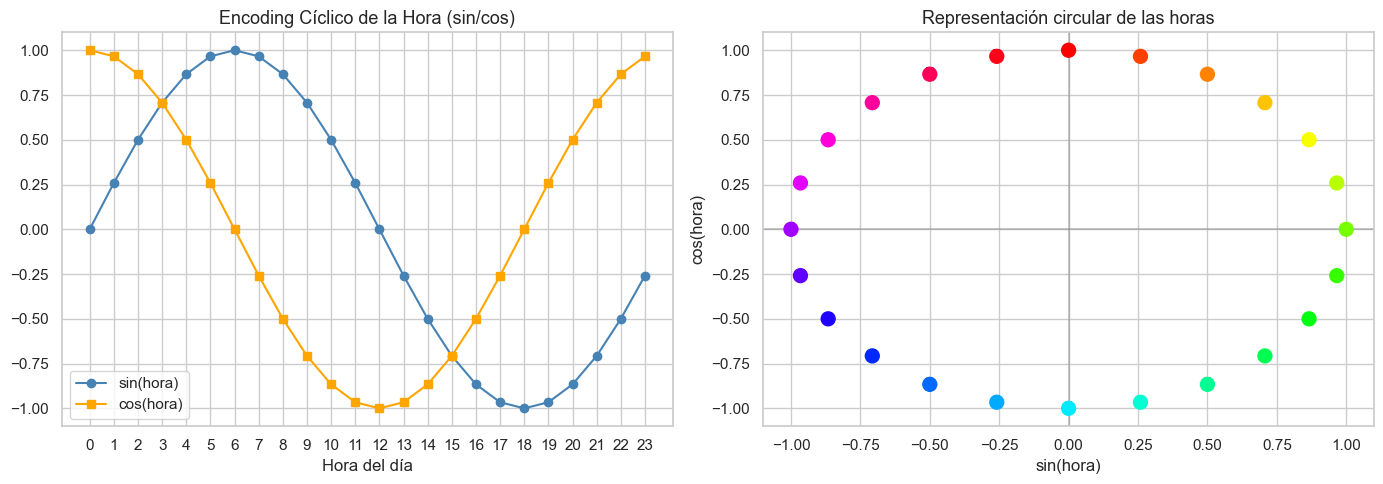

Observación: hora 23 y hora 0 están adyacentes en el círculo → el modelo las trata como contiguas.


In [5]:
# Visualizar el encoding cíclico de la hora
hours = np.arange(0, 24)
hour_sin = np.sin(2 * np.pi * hours / 24)
hour_cos = np.cos(2 * np.pi * hours / 24)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hours, hour_sin, marker='o', color='steelblue', label='sin(hora)')
axes[0].plot(hours, hour_cos, marker='s', color='orange', label='cos(hora)')
axes[0].set_title('Encoding Cíclico de la Hora (sin/cos)', fontsize=13)
axes[0].set_xlabel('Hora del día')
axes[0].legend()
axes[0].set_xticks(range(0, 24))

axes[1].scatter(hour_sin, hour_cos, c=hours, cmap='hsv', s=100, zorder=5)
for h in hours:
    axes[1].annotate(str(h), (hour_sin[h], hour_cos[h]), fontsize=7, ha='center')
axes[1].set_title('Representación circular de las horas', fontsize=13)
axes[1].set_xlabel('sin(hora)')
axes[1].set_ylabel('cos(hora)')
axes[1].axhline(0, color='gray', alpha=0.4)
axes[1].axvline(0, color='gray', alpha=0.4)

plt.tight_layout()
plt.savefig('../data/interim/03_cyclic_encoding.png', bbox_inches='tight', dpi=120)
plt.show()
print('Observación: hora 23 y hora 0 están adyacentes en el círculo → el modelo las trata como contiguas.')

**📝 Conclusión 2:** El encoding cíclico (sin/cos) es fundamental para variables periódicas como hora, día de semana y mes. Sin esto, un modelo lineal trataría las 23:00 y 00:00 como muy lejanas cuando en realidad son consecutivas.

---
## 3. Features Geográficas

Creamos indicadores de localización que capturan patrones de precio por zona.

In [6]:
def create_geographic_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Crea features geográficas a partir de boroughs y zonas.
    
    Nuevas columnas:
        - is_airport_trip (0/1): viaje con origen o destino en zonas de aeropuerto
        - is_jfk (0/1): JFK específicamente (tarifa fija $52 → rate_code 2)
        - is_newark (0/1): Newark (rate_code 3)
        - is_inter_borough (0/1): el viaje cruza de un borough a otro
        - is_manhattan_origin (0/1): origen en Manhattan
        - same_borough (0/1): origen y destino en el mismo borough
    """
    df = df.copy()
    
    # Zonas de aeropuerto conocidas en NYC
    AIRPORT_ZONES = {
        'JFK Airport', 'LaGuardia Airport', 'Newark Airport',
        'JFK', 'LGA', 'EWR'
    }
    
    # Indicador de aeropuerto por zona o rate_code
    airport_by_zone = False
    if 'pu_zone' in df.columns:
        airport_by_zone = df['pu_zone'].isin(AIRPORT_ZONES)
    if 'do_zone' in df.columns:
        airport_by_zone = airport_by_zone | df['do_zone'].isin(AIRPORT_ZONES)
    
    # También detectar por rate_code (2=JFK, 3=Newark)
    airport_by_rate = False
    if 'rate_code_id' in df.columns:
        airport_by_rate = df['rate_code_id'].isin([2, 3])
    
    df['is_airport_trip'] = (airport_by_zone | airport_by_rate).astype('int8')
    
    # JFK específico
    df['is_jfk'] = 0
    if 'rate_code_id' in df.columns:
        df['is_jfk'] = (df['rate_code_id'] == 2).astype('int8')
    elif 'rate_code_desc' in df.columns:
        df['is_jfk'] = df['rate_code_desc'].str.contains('JFK', na=False).astype('int8')
    
    # Newark específico
    df['is_newark'] = 0
    if 'rate_code_id' in df.columns:
        df['is_newark'] = (df['rate_code_id'] == 3).astype('int8')
    
    # Viaje inter-borough
    if 'pu_borough' in df.columns and 'do_borough' in df.columns:
        df['same_borough'] = (df['pu_borough'] == df['do_borough']).astype('int8')
        df['is_inter_borough'] = (~(df['pu_borough'] == df['do_borough'])).astype('int8')
    
    # Origen Manhattan (las tarifas suelen ser más altas)
    if 'pu_borough' in df.columns:
        df['is_manhattan_origin'] = (df['pu_borough'] == 'Manhattan').astype('int8')
    
    new_geo_features = ['is_airport_trip', 'is_jfk', 'is_newark', 'same_borough',
                        'is_inter_borough', 'is_manhattan_origin']
    created = [f for f in new_geo_features if f in df.columns]
    print(f'Features geográficas creadas: {created}')
    
    # Estadísticas de las nuevas features
    for feat in created:
        pct = df[feat].mean() * 100
        print(f'  {feat}: {pct:.1f}% de viajes')
    
    return df

df = create_geographic_features(df)
print(f'\nShape: {df.shape}')

Features geográficas creadas: ['is_airport_trip', 'is_jfk', 'is_newark', 'same_borough', 'is_inter_borough', 'is_manhattan_origin']
  is_airport_trip: 7.1% de viajes
  is_jfk: 2.2% de viajes
  is_newark: 0.2% de viajes
  same_borough: 87.3% de viajes
  is_inter_borough: 12.7% de viajes
  is_manhattan_origin: 85.9% de viajes

Shape: (2274211, 40)


---
## 4. Features de Interacción

Combinaciones entre variables que los árboles pueden aprender, pero damos una ventaja al modelo.

In [7]:
def create_interaction_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Crea ratios e interacciones entre variables existentes.
    
    IMPORTANTE: Solo usamos información disponible al inicio del viaje.
    trip_distance está disponible antes del viaje (se estima en el dispatch).
    
    Nuevas columnas:
        - distance_per_passenger: distancia total / pasajeros (proxy de costo por persona)
        - is_long_trip (0/1): viaje > 10 millas
        - is_short_trip (0/1): viaje < 1 milla (posibles outliers o viajes urbanos)
        - rush_airport: rush hour + aeropuerto (interacción costosa)
        - night_airport: noche + aeropuerto
        - night_manhattan: noche + origen Manhattan
    """
    df = df.copy()
    
    # Ratio distancia/pasajero
    if 'trip_distance' in df.columns and 'passenger_count' in df.columns:
        df['distance_per_passenger'] = (
            df['trip_distance'] / df['passenger_count'].clip(lower=1)
        ).astype('float32')
    
    # Segmentación de distancia
    if 'trip_distance' in df.columns:
        df['is_long_trip']  = (df['trip_distance'] > 10).astype('int8')
        df['is_short_trip'] = (df['trip_distance'] < 1).astype('int8')
    
    # Interacciones binarias (capturan efectos combinados)
    if 'is_rush_hour' in df.columns and 'is_airport_trip' in df.columns:
        df['rush_airport'] = (df['is_rush_hour'] & df['is_airport_trip']).astype('int8')
    
    if 'is_night' in df.columns and 'is_airport_trip' in df.columns:
        df['night_airport'] = (df['is_night'] & df['is_airport_trip']).astype('int8')
    
    if 'is_night' in df.columns and 'is_manhattan_origin' in df.columns:
        df['night_manhattan'] = (df['is_night'] & df['is_manhattan_origin']).astype('int8')
    
    new_interaction_features = [
        'distance_per_passenger', 'is_long_trip', 'is_short_trip',
        'rush_airport', 'night_airport', 'night_manhattan'
    ]
    created = [f for f in new_interaction_features if f in df.columns]
    print(f'Features de interacción creadas: {created}')
    
    return df

df = create_interaction_features(df)
print(f'\nShape: {df.shape}')

Features de interacción creadas: ['distance_per_passenger', 'is_long_trip', 'is_short_trip', 'rush_airport', 'night_airport', 'night_manhattan']

Shape: (2274211, 46)


---
## 5. Análisis de Importancia Empírica de las Nuevas Features

In [8]:
TARGET = 'total_amount'

new_features = [
    'is_weekend', 'is_rush_hour', 'is_night', 'is_holiday',
    'is_airport_trip', 'is_jfk', 'is_inter_borough', 'is_manhattan_origin',
    'is_long_trip', 'is_short_trip', 'rush_airport', 'night_airport'
]
new_features_present = [f for f in new_features if f in df.columns]

# Mean de total_amount por cada feature binaria (0 vs 1)
print('=== IMPACTO PROMEDIO EN total_amount (Media cuando = 1 vs cuando = 0) ===')
impacts = []
for feat in new_features_present:
    mean_0 = df[df[feat] == 0][TARGET].mean()
    mean_1 = df[df[feat] == 1][TARGET].mean()
    diff = mean_1 - mean_0
    pct = df[feat].mean() * 100
    impacts.append({'feature': feat, 'mean_0': mean_0, 'mean_1': mean_1, 'diff': diff, 'pct_cases': pct})
    print(f'  {feat:<25}: cuando=0 ${mean_0:.1f}, cuando=1 ${mean_1:.1f} | Δ ${diff:+.2f} ({pct:.1f}% de viajes)')

impact_df = pd.DataFrame(impacts).sort_values('diff', ascending=False, key=abs)

=== IMPACTO PROMEDIO EN total_amount (Media cuando = 1 vs cuando = 0) ===
  is_weekend               : cuando=0 $17.6, cuando=1 $17.0 | Δ $-0.59 (30.4% de viajes)
  is_rush_hour             : cuando=0 $17.4, cuando=1 $17.5 | Δ $+0.13 (25.8% de viajes)
  is_night                 : cuando=0 $17.4, cuando=1 $17.5 | Δ $+0.12 (31.5% de viajes)
  is_holiday               : cuando=0 $17.4, cuando=1 $17.2 | Δ $-0.21 (1.0% de viajes)
  is_airport_trip          : cuando=0 $14.6, cuando=1 $53.8 | Δ $+39.12 (7.1% de viajes)
  is_jfk                   : cuando=0 $16.3, cuando=1 $68.6 | Δ $+52.36 (2.2% de viajes)
  is_inter_borough         : cuando=0 $13.7, cuando=1 $42.7 | Δ $+28.95 (12.7% de viajes)
  is_manhattan_origin      : cuando=0 $29.5, cuando=1 $15.4 | Δ $-14.05 (85.9% de viajes)
  is_long_trip             : cuando=0 $14.7, cuando=1 $60.5 | Δ $+45.80 (5.9% de viajes)
  is_short_trip            : cuando=0 $20.1, cuando=1 $8.4 | Δ $-11.69 (23.2% de viajes)
  rush_airport             : cuando

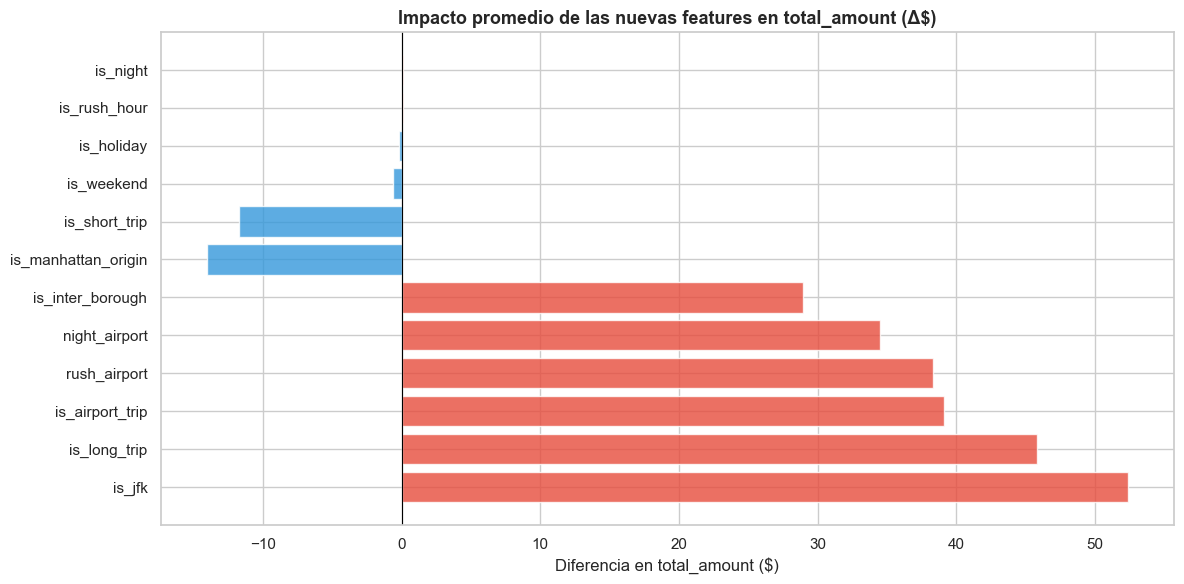

In [9]:
fig, ax = plt.subplots(figsize=(12, max(5, len(impacts) * 0.5)))
colors = ['#e74c3c' if d > 0 else '#3498db' for d in impact_df['diff']]
ax.barh(impact_df['feature'], impact_df['diff'], color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Impacto promedio de las nuevas features en total_amount (Δ$)', fontsize=13, fontweight='bold')
ax.set_xlabel('Diferencia en total_amount ($)')
plt.tight_layout()
plt.savefig('../data/interim/03_feature_impact.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 6. Definir Columnas del Modelo Final

In [10]:
TARGET = 'total_amount'

# Features numéricas continuas (StandardScaler)
NUMERIC_FEATURES = [
    'trip_distance',
    'passenger_count',
    'pickup_hour_sin',
    'pickup_hour_cos',
    'day_of_week_sin',
    'day_of_week_cos',
    'month_sin',
    'month_cos',
    'distance_per_passenger',
]

# Features numéricas de identificación de zona (OrdinalEncoder o embedding)
LOCATION_FEATURES = [
    'pu_location_id',
    'do_location_id',
]

# Features binarias (no necesitan escala, pasan directo)
BINARY_FEATURES = [
    'is_weekend',
    'is_rush_hour',
    'is_night',
    'is_holiday',
    'is_airport_trip',
    'is_jfk',
    'is_newark',
    'same_borough',
    'is_inter_borough',
    'is_manhattan_origin',
    'is_long_trip',
    'is_short_trip',
    'rush_airport',
    'night_airport',
    'night_manhattan',
]

# Features categóricas de baja cardinalidad (OneHotEncoder)
CATEGORICAL_LOW_CARD = [
    'vendor_name',
    'rate_code_desc',
    'payment_type_desc',
    'pu_borough',
    'do_borough',
    'source_service',
]

# Features categóricas de alta cardinalidad (OrdinalEncoder para boostings)
CATEGORICAL_HIGH_CARD = [
    'pu_zone',
    'do_zone',
]

# Consolidar listas filtrando solo las que están en el dataframe
def filter_available(cols, df):
    return [c for c in cols if c in df.columns]

NUMERIC_FEATURES   = filter_available(NUMERIC_FEATURES, df)
LOCATION_FEATURES  = filter_available(LOCATION_FEATURES, df)
BINARY_FEATURES    = filter_available(BINARY_FEATURES, df)
CAT_LOW            = filter_available(CATEGORICAL_LOW_CARD, df)
CAT_HIGH           = filter_available(CATEGORICAL_HIGH_CARD, df)

ALL_FEATURES = NUMERIC_FEATURES + LOCATION_FEATURES + BINARY_FEATURES + CAT_LOW + CAT_HIGH

print(f'Total features para modelado: {len(ALL_FEATURES)}')
print(f'  Numéricas continuas:   {len(NUMERIC_FEATURES)}')
print(f'  Ubicación (IDs):       {len(LOCATION_FEATURES)}')
print(f'  Binarias:              {len(BINARY_FEATURES)}')
print(f'  Categóricas baja card: {len(CAT_LOW)}')
print(f'  Categóricas alta card: {len(CAT_HIGH)}')
print(f'\nFeatures disponibles: {ALL_FEATURES}')

Total features para modelado: 34
  Numéricas continuas:   9
  Ubicación (IDs):       2
  Binarias:              15
  Categóricas baja card: 6
  Categóricas alta card: 2

Features disponibles: ['trip_distance', 'passenger_count', 'pickup_hour_sin', 'pickup_hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'distance_per_passenger', 'pu_location_id', 'do_location_id', 'is_weekend', 'is_rush_hour', 'is_night', 'is_holiday', 'is_airport_trip', 'is_jfk', 'is_newark', 'same_borough', 'is_inter_borough', 'is_manhattan_origin', 'is_long_trip', 'is_short_trip', 'rush_airport', 'night_airport', 'night_manhattan', 'vendor_name', 'rate_code_desc', 'payment_type_desc', 'pu_borough', 'do_borough', 'source_service', 'pu_zone', 'do_zone']


---
## 7. Pipeline de Preprocessing (ColumnTransformer)

Este pipeline es la base que irá a `src/features/build_features.py`. Configuramos dos versiones:
- **`preprocessor_linear`**: para modelos lineales (StandardScaler + OHE)
- **`preprocessor_tree`**: para árboles/boostings (solo encoding sin escala)

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

def build_preprocessor_for_trees(
    numeric_features: list,
    location_features: list,
    binary_features: list,
    cat_low_card: list,
    cat_high_card: list,
) -> ColumnTransformer:
    """
    Construye un ColumnTransformer optimizado para modelos de árbol/boosting.
    
    Estrategia por tipo de variable:
        - Numéricas continuas: imputación mediana (por si quedan nulos de chunks)
        - IDs de ubicación: pasar directo (los boostings los tratan como ordinales)
        - Binarias: pasar directo (ya son 0/1)
        - Categóricas baja cardinalidad: OrdinalEncoder (los árboles no necesitan OHE)
        - Categóricas alta cardinalidad: OrdinalEncoder con handle_unknown='use_encoded_value'
    
    Los modelos de boosting (XGBoost, LightGBM, CatBoost) NO necesitan StandardScaler;
    los árboles son invariantes a la escala.
    
    Returns:
        ColumnTransformer listo para fit/transform.
    """
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        # Sin escalado: los árboles son invariantes a la escala
    ])
    
    cat_low_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('encoder', OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1
        )),
    ])
    
    cat_high_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Other')),
        ('encoder', OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1
        )),
    ])
    
    transformers = []
    
    if numeric_features:
        transformers.append(('num', numeric_pipe, numeric_features))
    if location_features:
        transformers.append(('loc', 'passthrough', location_features))
    if binary_features:
        transformers.append(('bin', 'passthrough', binary_features))
    if cat_low_card:
        transformers.append(('cat_low', cat_low_pipe, cat_low_card))
    if cat_high_card:
        transformers.append(('cat_high', cat_high_pipe, cat_high_card))
    
    return ColumnTransformer(transformers=transformers, remainder='drop')


def build_preprocessor_for_linear(
    numeric_features: list,
    binary_features: list,
    cat_low_card: list,
) -> ColumnTransformer:
    """
    Preprocessor para modelos lineales (Regresión, Baseline).
    Usa StandardScaler en numéricas y OneHotEncoder en categóricas.
    """
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('encoder', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False,
            drop='first'
        )),
    ])
    
    transformers = []
    if numeric_features:
        transformers.append(('num', numeric_pipe, numeric_features))
    if binary_features:
        transformers.append(('bin', 'passthrough', binary_features))
    if cat_low_card:
        transformers.append(('cat', cat_pipe, cat_low_card))
    
    return ColumnTransformer(transformers=transformers, remainder='drop')


# Instanciar preprocessors
preprocessor_trees = build_preprocessor_for_trees(
    NUMERIC_FEATURES, LOCATION_FEATURES, BINARY_FEATURES, CAT_LOW, CAT_HIGH
)

preprocessor_linear = build_preprocessor_for_linear(
    NUMERIC_FEATURES, BINARY_FEATURES, CAT_LOW
)

print('✅ Preprocessors definidos.')
print(f'  preprocessor_trees: para XGBoost, LightGBM, CatBoost, RF, Bagging, Voting')
print(f'  preprocessor_linear: para Regresión Lineal (baseline)')

✅ Preprocessors definidos.
  preprocessor_trees: para XGBoost, LightGBM, CatBoost, RF, Bagging, Voting
  preprocessor_linear: para Regresión Lineal (baseline)


---
## 8. Prueba del Pipeline (Fit-Transform sobre la muestra)

In [12]:
# Verificación del pipeline con la muestra
df_model = df[ALL_FEATURES + [TARGET]].copy()
print(f'Dataset de modelado: {df_model.shape}')
print(f'Nulos en features: {df_model[ALL_FEATURES].isnull().sum().sum()}')

X = df_model[ALL_FEATURES]
y = df_model[TARGET]

# Test del preprocessor para trees
X_transformed = preprocessor_trees.fit_transform(X)
print(f'\n✅ preprocessor_trees.fit_transform OK')
print(f'   Shape entrada: {X.shape} → Shape salida: {X_transformed.shape}')

# Test del preprocessor lineal
X_lin = df_model[NUMERIC_FEATURES + BINARY_FEATURES + CAT_LOW]
X_lin_transformed = preprocessor_linear.fit_transform(X_lin)
print(f'\n✅ preprocessor_linear.fit_transform OK')
print(f'   Shape entrada: {X_lin.shape} → Shape salida: {X_lin_transformed.shape}')

Dataset de modelado: (2274211, 35)
Nulos en features: 54851

✅ preprocessor_trees.fit_transform OK
   Shape entrada: (2274211, 34) → Shape salida: (2274211, 34)

✅ preprocessor_linear.fit_transform OK
   Shape entrada: (2274211, 30) → Shape salida: (2274211, 49)


---
## 9. Pipeline Completo de Feature Engineering

In [14]:
def run_feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    """
    Pipeline completo de feature engineering.
    
    Encadena:
      1. create_temporal_features(): variables de tiempo
      2. create_geographic_features(): variables geográficas
      3. create_interaction_features(): interacciones y ratios
    
    Esta función va a src/features/build_features.py.
    
    Args:
        df: DataFrame limpio del notebook 02.
    
    Returns:
        DataFrame con todas las features generadas.
    """
    print('--- Feature Engineering ---')
    df = create_temporal_features(df)
    df = create_geographic_features(df)
    df = create_interaction_features(df)
    print(f'\n✅ Feature engineering completado. Shape: {df.shape}')
    return df

# Validación final
df_raw_test = pd.read_csv('../data/interim/clean_sample.csv')
df_engineered = run_feature_engineering(df_raw_test)
print(f'\nFeatures nuevas disponibles: {df_engineered.shape[1] - df_raw_test.shape[1]}')

--- Feature Engineering ---
Features temporales creadas: ['is_weekend', 'is_rush_hour', 'is_night', 'is_holiday', 'week_of_month', 'pickup_hour_sin', 'pickup_hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos']
Features geográficas creadas: ['is_airport_trip', 'is_jfk', 'is_newark', 'same_borough', 'is_inter_borough', 'is_manhattan_origin']
  is_airport_trip: 7.1% de viajes
  is_jfk: 2.2% de viajes
  is_newark: 0.2% de viajes
  same_borough: 87.3% de viajes
  is_inter_borough: 12.7% de viajes
  is_manhattan_origin: 85.9% de viajes
Features de interacción creadas: ['distance_per_passenger', 'is_long_trip', 'is_short_trip', 'rush_airport', 'night_airport', 'night_manhattan']

✅ Feature engineering completado. Shape: (2274211, 47)

Features nuevas disponibles: 23


---
## 10. Exportación del Dataset Final y Configuración del Modelo

In [15]:
import json

# Guardar dataset con features para el notebook 04
output_path = '../data/interim/engineered_sample.csv'
df_engineered.to_csv(output_path, index=False)
print(f'✅ Dataset con features guardado: {output_path}')

# Exportar configuración de columnas para src/
feature_config = {
    'target': TARGET,
    'numeric_features': NUMERIC_FEATURES,
    'location_features': LOCATION_FEATURES,
    'binary_features': BINARY_FEATURES,
    'cat_low_card': CAT_LOW,
    'cat_high_card': CAT_HIGH,
    'all_features': ALL_FEATURES,
}

config_path = '../data/interim/feature_config.json'
with open(config_path, 'w') as f:
    json.dump(feature_config, f, indent=2)

print(f'✅ Configuración de features guardada: {config_path}')
print(f'   Total features: {len(ALL_FEATURES)}')
print(f'   → Este archivo guía src/features/build_features.py y el notebook 04.')

✅ Dataset con features guardado: ../data/interim/engineered_sample.csv
✅ Configuración de features guardada: ../data/interim/feature_config.json
   Total features: 34
   → Este archivo guía src/features/build_features.py y el notebook 04.


---
## Resumen de Features Creadas

| Categoría | Features | Justificación |
|-----------|----------|---------------|
| **Temporales binarias** | is_weekend, is_rush_hour, is_night, is_holiday | Tarifas diferenciales en NYC |
| **Temporales cíclicas** | pickup_hour_sin/cos, day_sin/cos, month_sin/cos | Preserva continuidad circular |
| **Temporales adicionales** | week_of_month | Comportamiento fin/inicio de mes |
| **Geográficas** | is_airport_trip, is_jfk, is_newark | Tarifas fijas o especiales |
| **Geográficas** | same_borough, is_inter_borough, is_manhattan_origin | Patrón de precios por zona |
| **Interacciones** | rush_airport, night_airport, night_manhattan | Efectos combinados no lineales |
| **Ratios** | distance_per_passenger, is_long/short_trip | Segmentación de viajes |

**📦 Próximo paso**: El notebook 04 usa estas features y los preprocessors para experimentar con todos los modelos de boosting.